In [3]:
import sys
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
import torch.optim as optim
import matplotlib.pyplot as plt
# # import  settings

sys.path.append('..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/PINN/../exp_pybamm.py'>

In [ ]:
def gen_data(batches):
    I = np.zeros((batches,1,1000))
    V = np.zeros((batches,1,1000))
    for i in trange(batches):
        _, _, I[i,0,:], V[i,0,:] = exp_pybamm.get_values()
    return I, V

I_gen, V_gen = gen_data()

In [2]:
I = np.load('data_NO/I.npz')['arr_0']
V = np.load('data_NO/V.npz')['arr_0']


test_size = 0.1
I_test = I[0:int(test_size * len(I)),:,:]; V_test = V[0:int(test_size * len(I)),:,:]
I_train = I[int(test_size * len(I)):,:,:]; V_train = V[int(test_size * len(I)):,:,:]

FileNotFoundError: [Errno 2] No such file or directory: 'data_NO/I.npz'

In [30]:
from neuralop.models import FNO 
import torch
import torch.nn as nn

# Define the model
model = FNO(
    n_modes=(16,),         # number of Fourier modes
    hidden_channels=64, # width of the network
    in_channels=1,      # u(t) is 1D
    out_channels=1,      # y(t) is 1D
)

In [31]:
# from torch.utils.data import DataLoader, TensorDataset

# N, T = 1024, 64

# u = np.zeros((N, T,1))
# y = np.zeros((N, T,1))
# for i in trange(N):
#     w = random.uniform(0.5, 2.0)
#     u[i,:,0] = np.sin(w * np.linspace(0, 3.14, T))
#     y[i,:,0] = w*np.cos(w * np.linspace(0, 3.14, T))


# print(u.shape, y.shape  )

# dataset = TensorDataset(torch.tensor(u, dtype=torch.float32), 
#                         torch.tensor(y, dtype=torch.float32))

# loader = DataLoader(dataset, batch_size=32, shuffle=True)

# u_batch, y_batch = next(iter(loader))
# print(u_batch.shape)  # should be [32, 64, 1]


In [32]:
from torch.utils.data import DataLoader, TensorDataset


dataset = TensorDataset(torch.tensor(I, dtype=torch.float32), 
                        torch.tensor(V, dtype=torch.float32))

loader = DataLoader(dataset, batch_size=32, shuffle=True)

u_batch, y_batch = next(iter(loader))
print(u_batch.shape)  # should be [32, 64, 1]


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.HuberLoss()

torch.Size([32, 1, 1000])


In [34]:
def training(epochs = 50, tol = 2.5e-4, loader = loader, model = model, optimizer = optimizer, loss_fn = loss_fn):
    history = {'loss': []}
    for epoch in range(epochs):
        nb = 0 
        loss_sum = 0
        start_b = time.perf_counter()
        for u_batch, y_batch in loader:  # u_batch: [B, T, 1]
            y_pred = model(u_batch)
            loss = loss_fn(y_pred, y_batch)
            loss_sum += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            nb += 1
        end_b = time.perf_counter()
        ETA = (end_b-start_b)*(epochs-epoch-1)
        history['loss'].append(loss_sum/nb)
        if loss_sum / nb < tol:
            print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} Time: {int(ETA//60)}:{int(ETA%60):02d} - Early stopping')
            return model, history
        print(f'Epoch {epoch+1} average loss: {loss_sum/nb:.4f} ETA: {int(ETA//60)}:{int(ETA%60):02d}')
    return model, history

In [35]:
model, history = training(epochs=50, tol=2.5e-4, loader=loader, model=model, optimizer=optimizer, loss_fn=loss_fn)

Epoch 1 average loss: 3.0788 ETA: 3:14
Epoch 2 average loss: 2.4620 ETA: 3:03
Epoch 3 average loss: 0.6270 ETA: 3:03
Epoch 4 average loss: 0.1919 ETA: 3:05
Epoch 5 average loss: 0.0757 ETA: 2:51
Epoch 6 average loss: 0.0388 ETA: 2:46
Epoch 7 average loss: 0.0193 ETA: 2:42
Epoch 8 average loss: 0.0108 ETA: 2:38
Epoch 9 average loss: 0.0072 ETA: 2:34
Epoch 10 average loss: 0.0046 ETA: 2:30
Epoch 11 average loss: 0.0034 ETA: 2:28
Epoch 12 average loss: 0.0026 ETA: 2:25
Epoch 13 average loss: 0.0020 ETA: 2:25
Epoch 14 average loss: 0.0016 ETA: 2:33
Epoch 15 average loss: 0.0013 ETA: 2:24
Epoch 16 average loss: 0.0011 ETA: 2:18
Epoch 17 average loss: 0.0009 ETA: 2:12
Epoch 18 average loss: 0.0008 ETA: 2:07
Epoch 19 average loss: 0.0007 ETA: 2:02
Epoch 20 average loss: 0.0006 ETA: 2:18
Epoch 21 average loss: 0.0006 ETA: 2:10
Epoch 22 average loss: 0.0005 ETA: 1:50
Epoch 23 average loss: 0.0005 ETA: 1:55
Epoch 24 average loss: 0.0005 ETA: 1:38
Epoch 25 average loss: 0.0004 ETA: 1:55
Epoch 26 

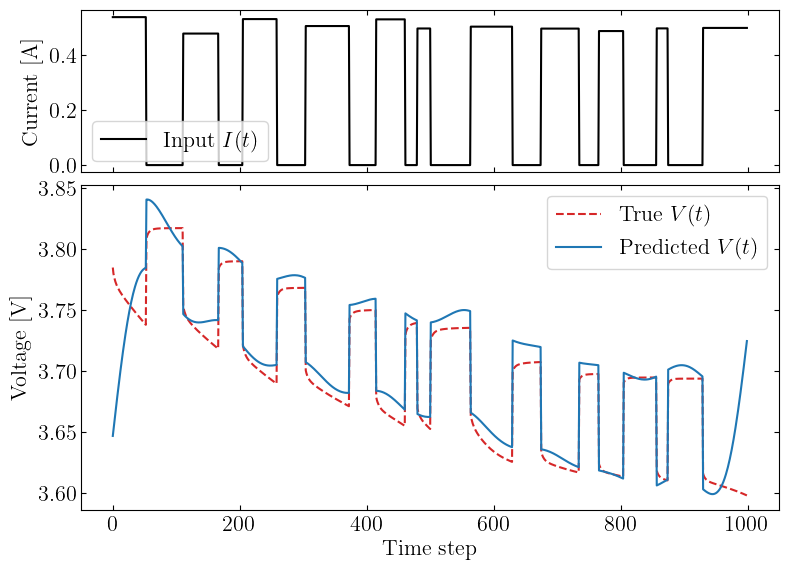

In [ ]:
test = 0
i = I_test[test,0,:].reshape(1, 1, 1000) 
v = V_test[test,0,:].reshape(1, 1, 1000)

#print(i.shape, v.shape)
y_pred = model(torch.tensor(i, dtype=torch.float32))
f, ax = plt.subplots(2,1,figsize=(9,6.5), gridspec_kw={'height_ratios': [.5, 1]}, sharex=True)
f.subplots_adjust(hspace=0.05)

ax[0].plot(i.ravel(), label='Input $I(t)$', color='black')
ax[1].plot(v.ravel(), label='True $V(t)$', color='tab:red', linestyle='dashed')
ax[1].plot(y_pred[0,0,:].detach().numpy(), label='Predicted $V(t)$', color='tab:blue')
ax[1].legend()
ax[0].legend()
ax[1].set_xlabel('Time step')
ax[0].set_ylabel('Current [A]')
ax[1].set_ylabel('Voltage [V]')
# plt.savefig('figs_NO/FNO_pred.pdf', bbox_inches='tight')

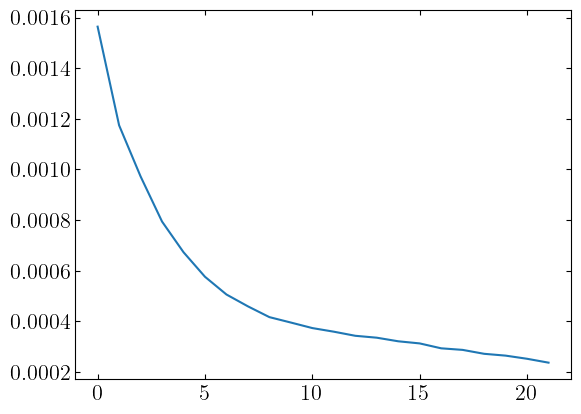

In [22]:
plt.plot(history['loss'])